# Cell-Cell Communication Analysis

This notebook demonstrates spatioloji_s's CCC module:

1. **Edge scoring** — score ligand-receptor communication on spatial graphs
2. **Significance testing** — analytical z-scores or subsampled permutation
3. **Interface-aware CCC** — stratify communication by spatial zone and measure gradients across tissue boundaries
4. **Morphology stratification** — compare communication across cell shape groups

No multi-layer pipeline — one simple scoring pass, then optional downstream analyses.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle


import spatioloji_s as sj
from spatioloji_s.ccc import CCCConfig, CCCResult, run_ccc
from spatioloji_s.ccc.halo import create_halo_subset, filter_ccc_to_core

# Load your spatioloji object
sp = sj.spatioloji.from_pickle('xenium_data/morph_xenium_spatioloji.pkl')

In [2]:
mapping = {
    0: "Tumor",
    1: "Tumor",
    2: "Stroma",
    3: "Myeloid",
    4: "T",
    5: "Tumor",
    6: "Stroma",
    7: "Stroma",
    8: "B"
}

sp.cell_meta['cell_type'] = sp.cell_meta['leiden'].map(mapping)
# Check what cell types are available
print(sp.cell_meta["cell_type"].value_counts())

cell_type
Tumor      640372
Stroma     236143
Myeloid    133860
T           90374
B           33806
Name: count, dtype: int64


## Built-in Ligand-Receptor Pairs in spatioloji_s CCC
### Juxtacrine (contact-dependent) — 13 pairs
#### Checkpoint / Immune Suppression

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| CD274_PDCD1 | CD274 | PDCD1 | PD-L1 checkpoint |
| CD80_CTLA4 | CD80 | CTLA4 | CTLA-4 checkpoint |
| CD86_CTLA4 | CD86 | CTLA4 | CTLA-4 checkpoint |
| TIGIT_PVR | TIGIT | PVR | TIGIT checkpoint |
| LGALS9_HAVCR2 | LGALS9 | HAVCR2 | TIM-3 checkpoint |
| CD276_TMIGD2 | CD276 | TMIGD2 | B7-H3 signaling |

#### Notch Signaling

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| DLL1_NOTCH1 | DLL1 | NOTCH1 | Notch signaling |
| DLL4_NOTCH1 | DLL4 | NOTCH1 | Notch signaling |
| JAG1_NOTCH1 | JAG1 | NOTCH1 | Notch signaling |

#### Ephrin Signaling

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| EFNA1_EPHA2 | EFNA1 | EPHA2 | Ephrin signaling |
| EFNB1_EPHB2 | EFNB1 | EPHB2 | Ephrin signaling |

#### MHC Signaling

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| HLA-A_CD8A | HLA-A | CD8A | MHC-I antigen presentation |
| HLA-DRA_CD4 | HLA-DRA | CD4 | MHC-II antigen presentation |

### Secreted (diffusible) — 20 pairs

#### Chemokines

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| CXCL12_CXCR4 | CXCL12 | CXCR4 | CXCL12 chemotaxis |
| CXCL10_CXCR3 | CXCL10 | CXCR3 | CXCL10 chemotaxis |
| CCL2_CCR2 | CCL2 | CCR2 | CCL2 chemotaxis |
| CCL5_CCR5 | CCL5 | CCR5 | CCL5 chemotaxis |
| CXCL8_CXCR1 | CXCL8 | CXCR1 | CXCL8 neutrophil |
| CXCL1_CXCR2 | CXCL1 | CXCR2 | CXCL1 neutrophil |

#### Heterodimeric Complexes

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| CXCL5\|PPBP_CXCR2 | CXCL5\|PPBP | CXCR2 | CXCL5/PPBP chemotaxis |
| IFNA2\|IFNB1_IFNAR1\|IFNAR2 | IFNA2\|IFNB1 | IFNAR1\|IFNAR2 | Type-I interferon |

#### Growth Factors

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| TGFB1_TGFBR1\|TGFBR2 | TGFB1 | TGFBR1\|TGFBR2 | TGF-beta signaling |
| VEGFA_FLT1 | VEGFA | FLT1 | VEGF angiogenesis |
| EGF_EGFR | EGF | EGFR | EGF signaling |
| HGF_MET | HGF | MET | HGF/c-Met signaling |
| IL6_IL6R | IL6 | IL6R | IL-6 signaling |
| IL10_IL10RA | IL10 | IL10RA | IL-10 anti-inflammatory |
| TNF_TNFRSF1A | TNF | TNFRSF1A | TNF signaling |
| IFNG_IFNGR1 | IFNG | IFNGR1 | IFN-gamma signaling |

#### Wnt Signaling

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| WNT5A_FZD1 | WNT5A | FZD1 | Wnt non-canonical |
| WNT2_FZD4 | WNT2 | FZD4 | Wnt canonical |

#### Angiopoietin

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| ANGPT1_TEK | ANGPT1 | TEK | Angiopoietin signaling |
| ANGPT2_TEK | ANGPT2 | TEK | Angiopoietin signaling |

### ECM (matrix-mediated) — 6 pairs

| LR Name | Ligand | Receptor | Pathway |
|---------|--------|----------|---------|
| FN1_ITGB1 | FN1 | ITGB1 | Fibronectin-integrin |
| COL1A1_ITGB1 | COL1A1 | ITGB1 | Collagen-integrin |
| LAMB1_ITGB1 | LAMB1 | ITGB1 | Laminin-integrin |
| THBS1_CD36 | THBS1 | CD36 | Thrombospondin signaling |
| SPP1_CD44 | SPP1 | CD44 | Osteopontin signaling |
| MMP9_CD44 | MMP9 | CD44 | MMP remodeling |

---
## 1. Define a Region of Interest (ROI) with Halo Correction

CCC analysis is computationally intensive -- a radius=200 graph on 1M+ cells produces hundreds of millions of edges. **Always subset to an ROI first.**

Three strategies for ROI selection:
1. **Bounding box** -- crop a spatial rectangle
2. **FOV subset** -- select specific fields of view
3. **Interface region** -- analyze cells near a tissue boundary

### Edge-cell problem

Cells at the ROI boundary lose neighbors that were cropped away, biasing their CCC scores downward. The **halo strategy** fixes this:
1. Enlarge the ROI by `max(secreted_radius, ecm_radius)` to include nearby "halo" cells
2. Run CCC on the enlarged set (edge cells now see their true neighbors)
3. Filter results back to core ROI cells only

In [ ]:
# Strategy 1: Bounding box -- crop a spatial rectangle
x = sp.spatial.x_global
y = sp.spatial.y_global

# Adjust these coordinates to your tissue region of interest
x_min, x_max = 2000, 4000
y_min, y_max = 11000, 13000

mask = (x > x_min) & (x < x_max) & (y > y_min) & (y < y_max)
roi_cells = sp.cell_index[mask]
sp_roi = sp.subset_by_cells(roi_cells)
print(f"ROI: {len(sp_roi.cell_index):,} cells (from {len(sp.cell_index):,})")
print(sp_roi.cell_meta["cell_type"].value_counts())

In [ ]:
# Create halo-enlarged subset for edge-cell correction
# halo_distance defaults to max(secreted_radius, ecm_radius) from config
config = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    secreted_radius=200.0,
    ecm_radius=200.0,
    buffer_distance=2,
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config)
print(f"\nWith halo: {sp_halo.n_cells:,} cells ({sp_halo.n_cells - len(core_ids):,} halo cells added)")

In [4]:
# Strategy 2: FOV subset — select specific fields of view
# sp_roi = sp.subset_by_fovs(["fov_01", "fov_02"])

In [5]:
# Strategy 3: Interface region — cells near the tumor-stroma boundary
# import spatioloji_s.spatial.point as spoint
# from spatioloji_s.spatial._distance_utils import signed_distance_to_interface
#
# iface = spoint.identify_interface(sp, group_col="cell_type",
#     region_a="Tumor", region_b="Stroma", grid_resolution=50)
# distances = signed_distance_to_interface(sp, iface)
# near_interface = sp.cell_index[distances.abs() < 500]  # within 500 um of boundary
# sp_roi = sp.subset_by_cells(near_interface)

In [ ]:
# Visualize your ROI with halo
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full tissue with ROI box + halo
ax = axes[0]
ax.scatter(sp.spatial.x_global, sp.spatial.y_global, s=0.1, c="lightgray", alpha=0.3)
halo_only = sp_halo.cell_index.difference(core_ids)
halo_mask = sp_halo.cell_index.isin(halo_only)
ax.scatter(sp_halo.spatial.x_global[halo_mask.values], sp_halo.spatial.y_global[halo_mask.values],
           s=0.5, c="orange", alpha=0.5, label="Halo")
core_mask = sp_halo.cell_index.isin(core_ids)
ax.scatter(sp_halo.spatial.x_global[core_mask.values], sp_halo.spatial.y_global[core_mask.values],
           s=0.5, c="red", alpha=0.5, label="Core ROI")
ax.set_title(f"Full tissue ({len(sp.cell_index):,} cells) + Core (red) + Halo (orange)")
ax.set_aspect("equal")
ax.invert_yaxis()
ax.legend(markerscale=10, fontsize=10)

# ROI colored by cell type
ax = axes[1]
for ct in sp_roi.cell_meta["cell_type"].unique():
    mask = sp_roi.cell_meta["cell_type"] == ct
    ax.scatter(
        sp_roi.spatial.x_global[mask.values],
        sp_roi.spatial.y_global[mask.values],
        s=10, label=ct, alpha=0.5,
    )
ax.set_title(f"ROI: {len(sp_roi.cell_index):,} cells")
ax.set_aspect("equal")
ax.invert_yaxis()
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Run CCC on ROI (with Halo Correction)

Run CCC on the halo-enlarged `sp_halo`, then filter results back to core ROI cells. This ensures edge cells score their true neighbors without boundary artifacts.

In [ ]:
# Run CCC on halo-enlarged ROI
result_halo = run_ccc(sp_halo, config)

# Filter results back to core ROI cells only
result = filter_ccc_to_core(result_halo, core_ids, sp_core=sp_roi)

# Top significant interactions
sig = result.scores[result.scores["fdr"] < 0.05].sort_values("mean_score", ascending=False)
print(f"{len(sig)} significant interactions (FDR < 0.05)")
sig.head(20)

In [ ]:
# Run with sender/receiver filter on halo ROI
config_filtered = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    sender_types=["Stroma"],
    receiver_types=["Tumor"],
    buffer_distance=5
)

# Rebuild halo for this config (buffer_distance differs, but halo uses max of secreted/ecm radius)
sp_halo_filt, core_ids_filt = create_halo_subset(sp, roi_cells, config=config_filtered)
result_filt = run_ccc(sp_halo_filt, config_filtered)
result = filter_ccc_to_core(result_filt, core_ids_filt, sp_core=sp_roi)

# Top significant interactions
sig = result.scores[result.scores["fdr"] < 0.05].sort_values("mean_score", ascending=False)
print(f"{len(sig)} significant interactions (FDR < 0.05)")
sig.head(20)

---
## 3. Custom Configuration

### 3a. Using CellChatDB

Load a larger LR database from CellChatDB CSV.

In [ ]:
# Use CellChatDB -- download from https://github.com/sqjin/CellChat
config = CCCConfig(
    db_source="cellchatdb",
    db_csv_path="my_ref/CellChatDB_human.csv",  # adjust path
    group_col="cell_type",
    layer="log_normalized",
    min_pct=0.2,
    buffer_distance=2
)

# Run with halo correction
sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config)
result_halo = run_ccc(sp_halo, config)
result = filter_ccc_to_core(result_halo, core_ids, sp_core=sp_roi)
print(f"{len(result.lr_pairs)} LR pairs tested")
print(f"{len(result.scores)} type-pair interactions scored")

In [13]:
with open('xenium_data/ccc_result.pkl', 'wb') as f:
    pickle.dump(result, f)

print('saved')

saved


In [14]:
with open('xenium_data/ccc_result.pkl', 'rb') as f:
    result = pickle.load(f)

In [14]:
# Top significant interactions
sig = result.scores[result.scores["fdr"] < 0.05].sort_values("mean_score", ascending=False)
print(f"{len(sig)} significant interactions (FDR < 0.05)")
sig.head(20)

386 significant interactions (FDR < 0.05)


,lr_name,sender_type,receiver_type,mean_score,sum_score,n_edges,z_score,pvalue,fdr
1039,THBS1_CD47,Stroma,Tumor,0.948850,1.565500e+06,1649892,138.212570,0.0,0.0
805,LGALS9_P4HB,Myeloid,B,0.823156,1.338534e+04,16261,100.047589,0.0,0.0
238,COL4A1_CD44,Stroma,T,0.790113,8.207619e+04,103879,354.132281,0.0,0.0
1036,THBS1_CD47,Stroma,Myeloid,0.788809,2.169255e+05,275004,187.930415,0.0,0.0
1035,THBS1_CD47,Stroma,B,0.777534,3.954069e+04,50854,162.076982,0.0,0.0
1038,THBS1_CD47,Stroma,T,0.745759,7.746869e+04,103879,153.856751,0.0,0.0
1029,THBS1_CD47,B,Tumor,0.718596,9.149663e+04,127327,135.531030,0.0,0.0
806,LGALS9_P4HB,Myeloid,Myeloid,0.686931,1.074690e+05,156448,259.515366,0.0,0.0
1089,THBS2_CD47,Stroma,Tumor,0.670232,1.105811e+06,1649892,450.350214,0.0,0.0
808,LGALS9_P4HB,Myeloid,T,0.656978,2.771986e+04,42193,106.573653,0.0,0.0


### 3b. Configuring spatial parameters

Default radius is 200 um for secreted/ECM signaling (matches COMMOT's paracrine diffusion range).

In [ ]:
config = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    secreted_radius=200.0,
    ecm_radius=200.0,
    buffer_distance=None,         # None = direct polygon contact for juxtacrine
    sigma_secreted=None,          # auto-estimated from median edge distance
    sigma_ecm=None,
    lr_types=["secreted", "ecm"],  # or ["juxtacrine"] or None for all
)

result = run_ccc(sp_roi, config)

### 3c. Significance testing

Two methods:
- **Analytical** (default) — z-score from null distribution moments. Fast.
- **Permutation** — subsampled cells, shuffled labels. More robust for rare cell types.

In [ ]:
# Permutation test (more robust, slower)
config_perm = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    test_method="permutation",
    n_subsample=5000,
    n_permutations=1000,
    seed=42,
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config_perm)
result_perm = run_ccc(sp_halo, config_perm)
result_perm = filter_ccc_to_core(result_perm, core_ids, sp_core=sp_roi)

### 3d. Filter to specific cell types

In [ ]:
# Only score Tumor -> immune interactions
config_filtered = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    sender_types=["Tumor"],
    receiver_types=["T", "Myeloid", "B"],
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config_filtered)
result_filtered = run_ccc(sp_halo, config_filtered)
result_filtered = filter_ccc_to_core(result_filtered, core_ids, sp_core=sp_roi)
print(result_filtered.scores.sort_values("mean_score", ascending=False).head(10))

---
## 4. Visualizing Results

### 4a. Score heatmap — sender x receiver

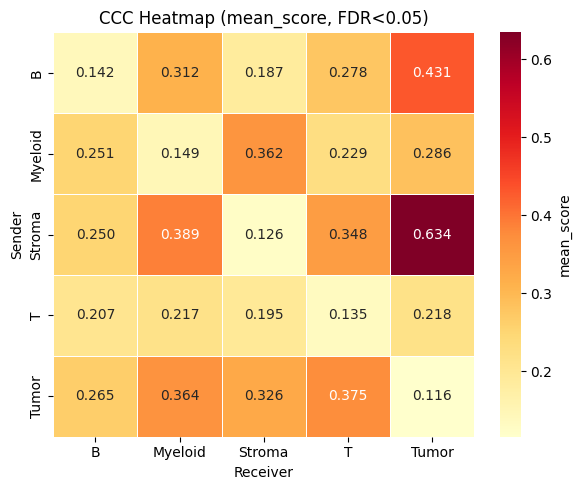

In [17]:
# Heatmap aggregated across all significant LR pairs
sj.visualization.plot_ccc_heatmap(result)


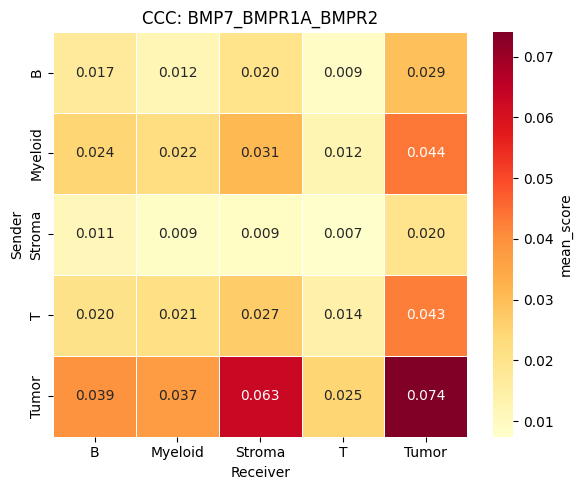

In [18]:
# Heatmap for a specific LR pair
sj.visualization.plot_ccc_heatmap(result, lr_name="BMP7_BMPR1A_BMPR2")

### 4b. Dot plot — top interactions ranked by score

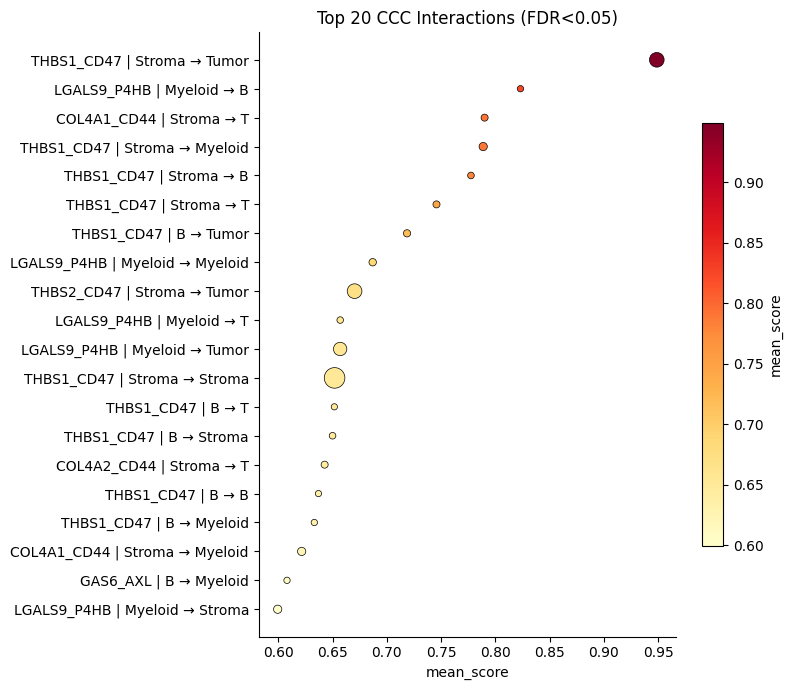

In [19]:
# Top 20 significant interactions (dot size = n_edges, color = score)
sj.visualization.plot_ccc_dotplot(result, top_n=20)

### 4c. Communication network — cell type level

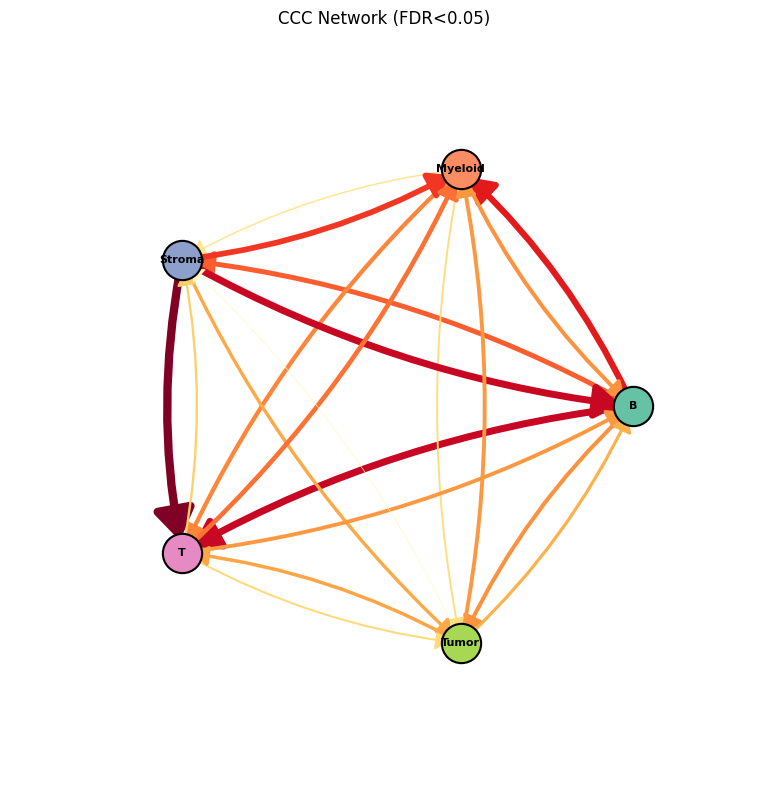

In [20]:
# Directed network: nodes = cell types, edges = total communication score
sj.visualization.plot_ccc_network(result)

### 4d. Spatial map — per-cell sender/receiver scores

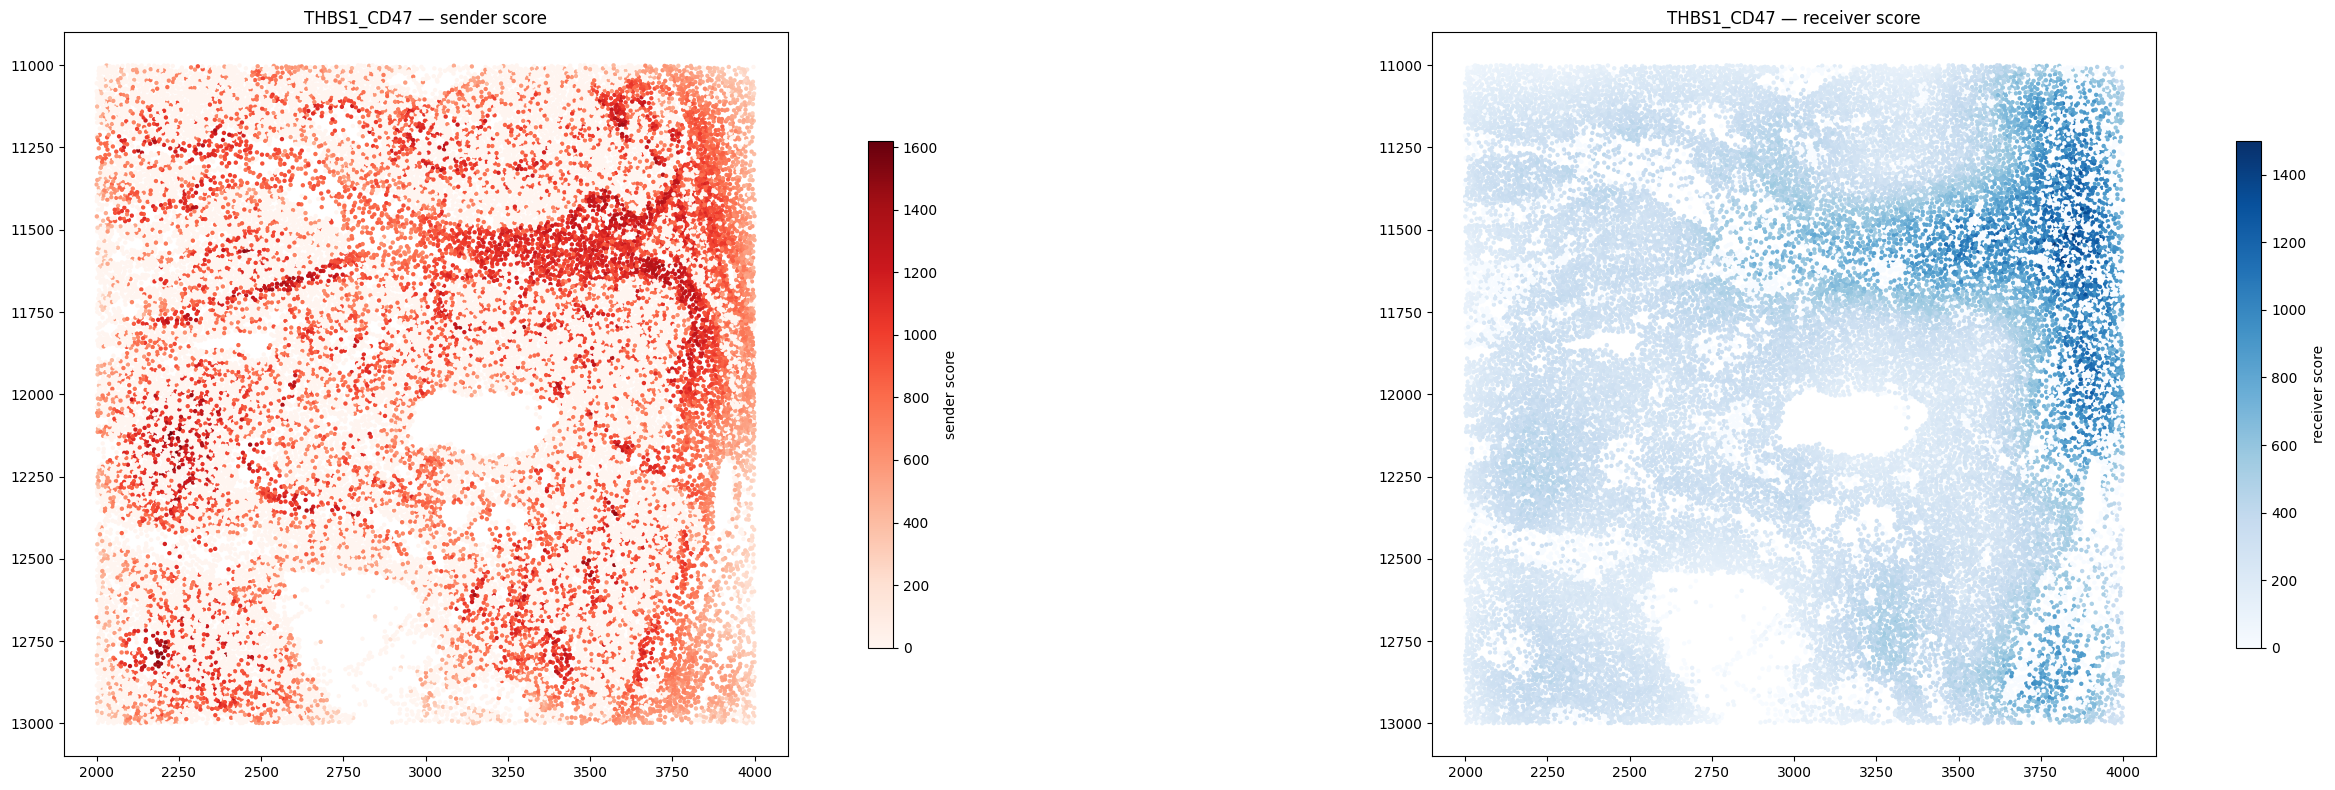

In [21]:
top_lr = result.scores.sort_values("mean_score", ascending=False).iloc[0]["lr_name"]                                                                                                                             
                                                                                                                                                                                                               
fig, axes = plt.subplots(1, 2, figsize=(30, 8))                                                                                                                                                                  
                                                                                                                                                                                                               
# 1. Sender scores
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name=top_lr, role="sender",
                                cmap="Reds", ax=axes[0], show=False, point_size=10)                                                                                                                            

# 2. Receiver scores                                                                                                                                                                                             
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name=top_lr, role="receiver",
                                cmap="Blues", ax=axes[1], show=False, point_size=10)                                                                                                                                                                                                                                                                           
              
plt.tight_layout()                                                                                                                                                                                               
plt.show() 

  Saved: xenium_plots/xenium_cell_type_dot_categorical.png


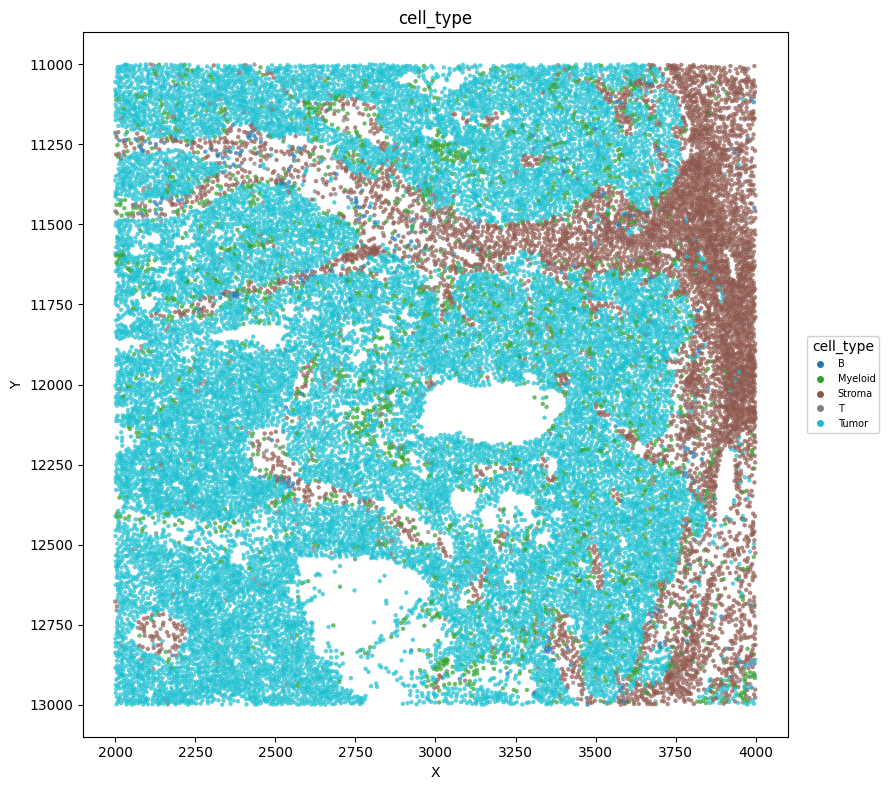

In [22]:
# 3. Cell type map using your built-in plot                                                                                                                                                                      
sj.visualization.xenium_plot_spatial(sp_roi, 
                                     values='cell_type', 
                                     save_dir='xenium_plots',
                                     mode='dot', 
                                     show=True, dot_size=10) 

Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 29868 cells
  Saved: xenium_plots/xenium_cell_type_polygon_categorical.png


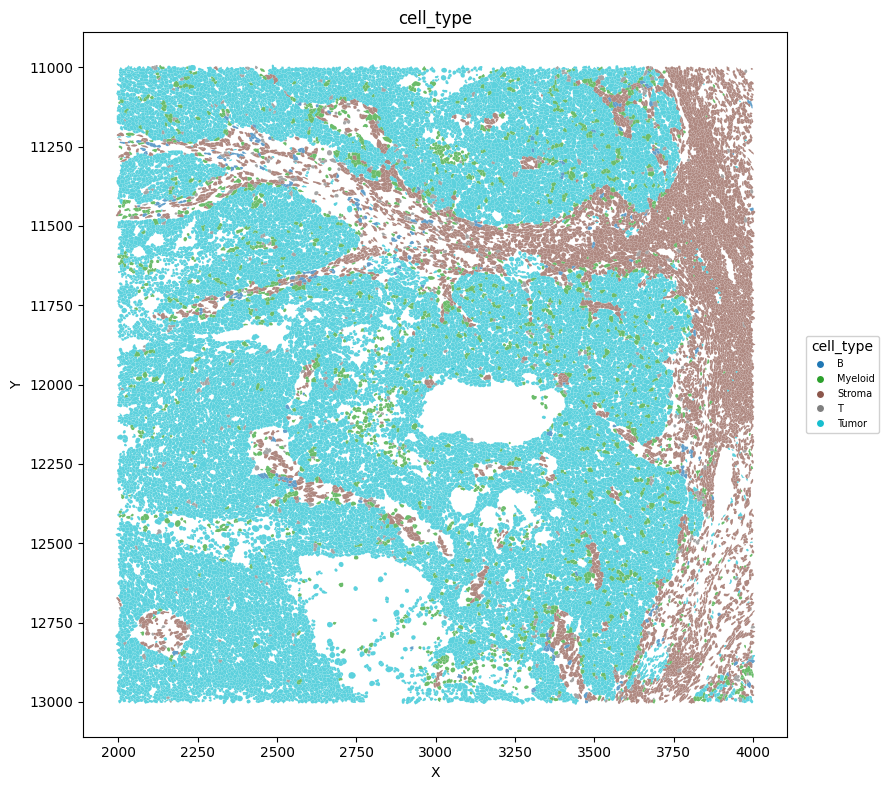

In [23]:
sj.visualization.xenium_plot_spatial(sp_roi, 
                                     values='cell_type', 
                                     save_dir='xenium_plots',
                                     mode='polygon', 
                                     show=True) 

---
## 5. Interface-Aware CCC

**What makes spatioloji_s unique:** stratify communication by spatial zone relative to a tissue boundary.

### 5a. Run CCC with interface

In [ ]:
import spatioloji_s.spatial.point as spoint

# Identify interface on the ROI
iface = spoint.identify_interface(
    sp_roi, group_col="cell_type",
    region_a="Tumor", region_b="Stroma",
    grid_resolution=50,
)

# Run CCC with interface awareness (using halo correction)
config_iface = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    interface_result=iface,
    n_distance_bins=20,
    buffer_distance=2,
    db_source="cellchatdb",
    db_csv_path="my_ref/CellChatDB_human.csv",
    min_pct=0.2,
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config_iface)
result_iface = run_ccc(sp_halo, config_iface)
result_iface = filter_ccc_to_core(result_iface, core_ids, sp_core=sp_roi)

In [5]:
with open('xenium_data/result_iface.pkl', 'wb') as f:
    pickle.dump(result_iface, f)

print('saved')

saved


In [4]:
with open('xenium_data/result_iface.pkl', 'rb') as f:
    result_iface = pickle.load(f)

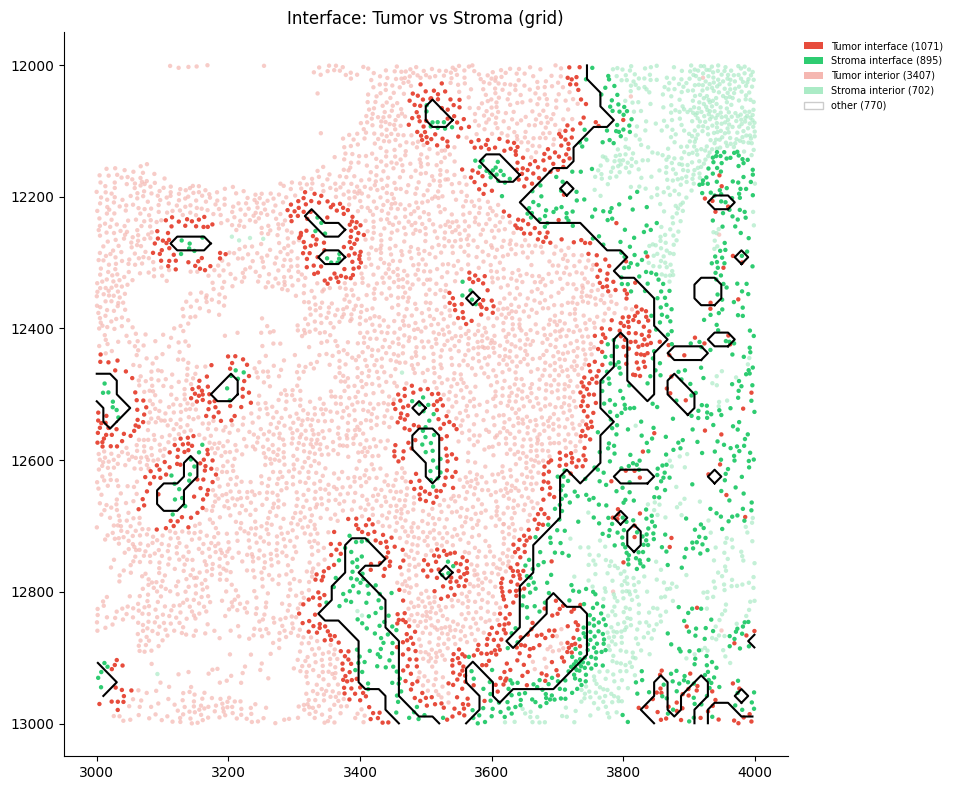

In [6]:
sj.visualization.plot_interface_point_map(
    sp_roi, iface,
    color_a='#e74c3c',     # red for region A
    color_b='#2ecc71',     # green for region B
    point_size=10,
    contour_width=1.5,
    dpi=200, show_seg_labels=False
)

In [7]:
iface

InterfaceResult(cell_labels=cell_id
dcjebgcm-1                 other
dcjeeade-1                 other
dcjmclem-1                 other
dcjmdfai-1    region_b_interface
dcjmdidk-1                 other
                     ...        
oikhlpio-1                 other
oikhmbpg-1            interior_a
oiklabnb-1    region_a_interface
oiklcbjk-1            interior_a
oikldcmf-1    region_a_interface
Length: 6845, dtype: object, contour=<MULTILINESTRING ((3928.424 12999.57, 3928.424 12978.959, 3938.625 12968.548...>, segments=    segment_id                                           geometry  \
0            0  LINESTRING (3928.424 12999.57, 3928.424 12978....   
1            1  LINESTRING (3998.998 12884.4, 3989.633 12874.8...   
2            2  LINESTRING (3744.798 12000.483, 3744.798 12021...   
3            3  LINESTRING (3846.641 12999.608, 3836.611 12989...   
4            4  LINESTRING (3540.77 12083.54, 3530.568 12073.1...   
5            5  LINESTRING (3642.784 12166.835, 3632.583 12

## top ranks based on fold_change
fold_change = zone_mean_score / overall_mean_score                                                                                             
Specifically:                                                                                                                                  
  1. overall_mean (line 116): mean of score across all edges for each (lr_name, sender_type, receiver_type) group, regardless of zone            
  2. zone_mean_score (line 129): mean of score for edges in that specific zone (interface, interior_a, or interior_b)
  3. fold_change (line 155): zone_mean_score / overall_mean_score (NaN if overall is 0)

  So a fold_change of 2.0 at the interface means that interaction is 2x stronger at the interface than the global average. The plotting function 
  then ranks by interface fold_change descending — interactions most enriched at the interface appear first.

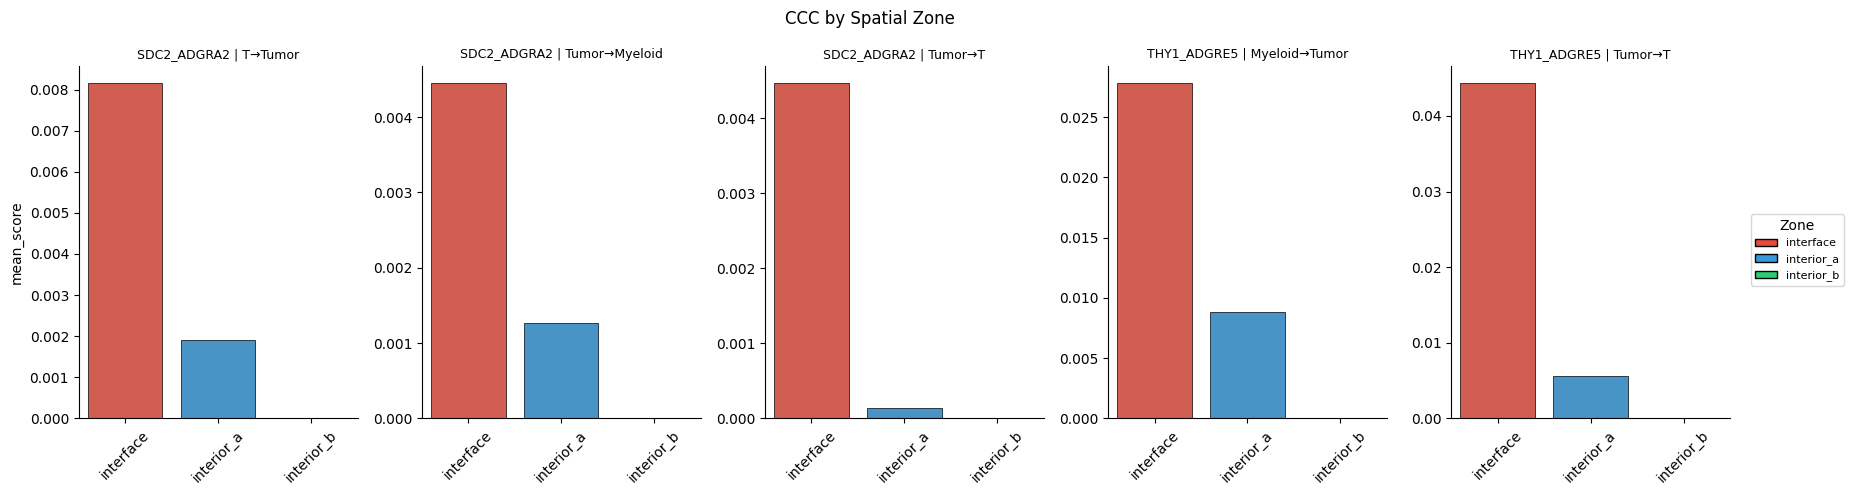

In [8]:
# Zone comparison: grouped bar chart (interface vs interior_a vs interior_b)
# any edge where at least one end is a Tumor or Stroma cell is included. Only edges where both sender and receiver are non-Tumor/non-Stroma are dropped
sj.visualization.plot_ccc_zones(result_iface, top_n=5)

### 5b. Communication gradient

Horizontal bar chart of gradient slopes. Solid = significant (p < 0.05), hatched = non-significant.

In [11]:
result_iface

CCCResult(scores=          lr_name sender_type receiver_type  mean_score   sum_score  n_edges  \
0       APP_SORL1           B             B    0.056659    2.946275       52   
1       APP_SORL1           B       Myeloid    0.047662    0.857914       18   
2       APP_SORL1           B        Stroma    0.011772    0.965313       82   
3       APP_SORL1           B             T    0.003464    0.034641       10   
4       APP_SORL1           B         Tumor    0.042767    1.625127       38   
...           ...         ...           ...         ...         ...      ...   
1120  THY1_ADGRE5       Tumor             B    0.013364    0.507820       38   
1121  THY1_ADGRE5       Tumor       Myeloid    0.020027   28.517770     1424   
1122  THY1_ADGRE5       Tumor        Stroma    0.020942    9.214626      440   
1123  THY1_ADGRE5       Tumor             T    0.019624    5.318170      271   
1124  THY1_ADGRE5       Tumor         Tumor    0.012459  263.860805    21178   

        z_score       

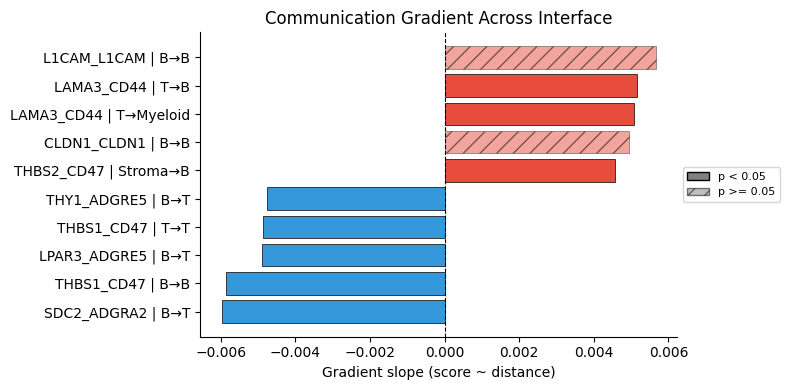

In [12]:
# Gradient slopes — which interactions change most across the interface?
sj.visualization.plot_ccc_gradient(result_iface, top_n=10)

---
## 6. Morphology Stratification

Compare communication patterns across cell shape groups.

In [ ]:
# Run CCC with morphology stratification (using halo correction)
config_morph = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    morphology_col="morph_class",
    buffer_distance=2,
    db_source="cellchatdb",
    db_csv_path="my_ref/CellChatDB_human.csv",
    min_pct=0.2,
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config_morph)
result_morph = run_ccc(sp_halo, config_morph)
result_morph = filter_ccc_to_core(result_morph, core_ids, sp_core=sp_roi)

In [7]:
with open('xenium_data/result_morph.pkl', 'wb') as f:
    pickle.dump(result_morph, f)

print('saved')

saved


In [ ]:
with open('xenium_data/result_morph.pkl', 'rb') as f:
    result_morph = pickle.load(f)

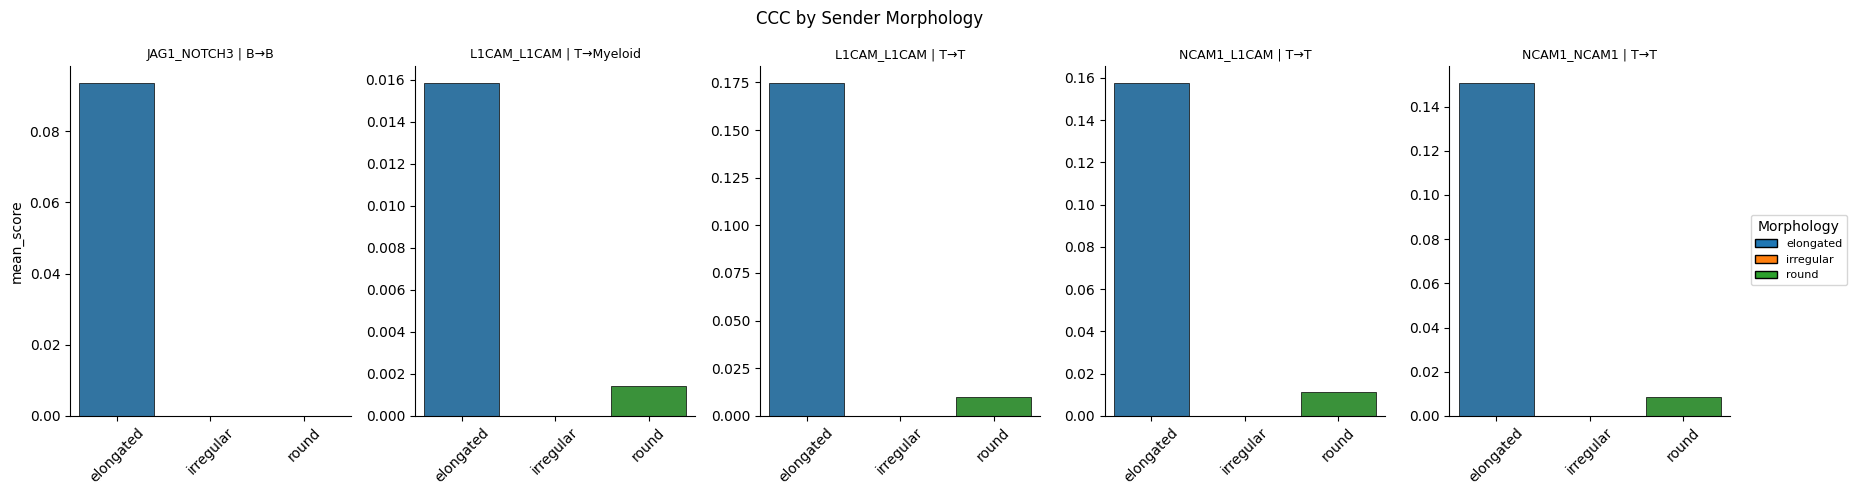

In [10]:
# Grouped bar chart by morphology
sj.visualization.plot_ccc_morphology(result_morph, top_n=5)

---
## 7. Summary Panel — All Plots Together

In [ ]:
# Run full pipeline with halo correction
config_full = CCCConfig(
    group_col="cell_type",
    layer="log_normalized",
    interface_result=iface,
    n_distance_bins=20,
    morphology_col="morph_class",
)

sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config_full)
result_full = run_ccc(sp_halo, config_full)
result_full = filter_ccc_to_core(result_full, core_ids, sp_core=sp_roi)

# Multi-panel summary
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

# Row 1: core results
sj.visualization.plot_ccc_heatmap(result_full, ax=axes[0, 0], show=False, title="Score Heatmap")
sj.visualization.plot_ccc_network(result_full, show=False)  # network needs its own fig
top_lr = result_full.scores.sort_values("mean_score", ascending=False).iloc[0]["lr_name"]
sj.visualization.plot_ccc_spatial(sp_roi, result_full, lr_name=top_lr, role="sender", ax=axes[0, 1], show=False)
sj.visualization.plot_ccc_spatial(sp_roi, result_full, lr_name=top_lr, role="receiver", cmap="Blues", ax=axes[0, 2], show=False)

# Row 2: interface + morphology
sj.visualization.plot_ccc_zones(result_full, top_n=5, ax=axes[1, 0], show=False)
sj.visualization.plot_ccc_gradient(result_full, top_n=5, ax=axes[1, 1], show=False)
sj.visualization.plot_ccc_morphology(result_full, top_n=5, ax=axes[1, 2], show=False)

plt.suptitle("CCC Analysis Summary", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Low-Level API

Use scoring functions directly for custom analyses.

In [ ]:
from spatioloji_s.ccc.database import LRPair, load_lr_database, filter_to_expressed
from spatioloji_s.ccc.scoring import score_edges, aggregate_scores, test_significance
from spatioloji_s.ccc.zones import compare_zones, communication_gradient, compare_morphology
from spatioloji_s.spatial.point.graph import build_radius_graph

# 1. Load and filter LR pairs
pairs = load_lr_database("builtin")
pairs = filter_to_expressed(pairs, sp_roi, min_pct=0.05)
print(f"{len(pairs)} expressed LR pairs")

# 2. Build graph on ROI
graph = build_radius_graph(sp_roi, radius=200, coord_type="global")

# 3. Score edges
edges = score_edges(sp_roi, pairs, graph_diffusible=graph, group_col="cell_type", layer="log_normalized")
print(f"{len(edges)} edges scored")

# 4. Aggregate
summary, cell_scores = aggregate_scores(edges, sp_roi, group_col="cell_type")

# 5. Test significance
summary = test_significance(summary, edges, sp_roi, group_col="cell_type", method="analytical")

# 6. Zone comparison (requires interface result)
zone_df = compare_zones(edges, sp_roi, iface, group_col="cell_type")

# 7. Communication gradient
grad_df = communication_gradient(edges, sp_roi, iface, group_col="cell_type", n_bins=20)

---
## Quick Reference

```python
from spatioloji_s.ccc import CCCConfig, run_ccc
from spatioloji_s.ccc.halo import create_halo_subset, filter_ccc_to_core

# -- Step 1: Define ROI and create halo subset --
x, y = sp.spatial.x_global, sp.spatial.y_global
roi_cells = sp.cell_index[(x > x_min) & (x < x_max) & (y > y_min) & (y < y_max)]
sp_roi = sp.subset_by_cells(roi_cells)

config = CCCConfig(group_col="cell_type", secreted_radius=200.0)
sp_halo, core_ids = create_halo_subset(sp, roi_cells, config=config)

# -- Step 2: Run CCC on halo-enlarged ROI --
result = run_ccc(sp_halo, config)
result = filter_ccc_to_core(result, core_ids, sp_core=sp_roi)

# -- Variants --
result = run_ccc(sp_halo, CCCConfig(db_source="cellchatdb", db_csv_path="CellChatDB.csv"))
result = run_ccc(sp_halo, CCCConfig(test_method="permutation", n_subsample=5000))
result = run_ccc(sp_halo, CCCConfig(sender_types=["Tumor"], receiver_types=["T"]))

# -- Interface-aware --
iface = spoint.identify_interface(sp_roi, group_col="cell_type",
    region_a="Tumor", region_b="Stroma")
result = run_ccc(sp_halo, CCCConfig(interface_result=iface))
result = filter_ccc_to_core(result, core_ids, sp_core=sp_roi)

# -- Morphology --
result = run_ccc(sp_halo, CCCConfig(morphology_col="morph_class"))
result = filter_ccc_to_core(result, core_ids, sp_core=sp_roi)

# -- Step 3: Visualize --
sj.visualization.plot_ccc_heatmap(result)                           # sender x receiver heatmap
sj.visualization.plot_ccc_dotplot(result, top_n=20)                 # top interactions dot plot
sj.visualization.plot_ccc_network(result)                           # cell type network
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name, "sender")# spatial sender scores
sj.visualization.plot_ccc_spatial(sp_roi, result, lr_name, "receiver", cmap="Blues")
sj.visualization.plot_ccc_zones(result, top_n=10)                   # zone bar chart
sj.visualization.plot_ccc_gradient(result, top_n=10)                # gradient slopes
sj.visualization.plot_ccc_morphology(result, top_n=10)              # morphology bar chart
```